# Spain vs Argentina — 2026 World Cup Final ML Forecast

**Fixture:** Spain vs Argentina, 19 July 2026, East Rutherford (neutral venue)  
**Question:** who will lift the trophy, not merely lead after 90 minutes?

This notebook builds a reproducible, leakage-safe forecast from men's senior international results. It combines:

1. a dynamic Elo model;
2. a regularized multinomial outcome classifier;
3. gradient-boosted outcome probabilities;
4. independent Poisson goal models and Monte Carlo match simulation.

The result is a probability distribution, not a certainty. Injuries, lineups, tactics, red cards, and randomness are not fully represented.

## How to read this notebook

You do **not** need a machine-learning background. The model is a chain of fairly simple ideas:

1. Read old match results.
2. Before every historical match, summarize what was known about each team at that moment.
3. Show several algorithms those summaries and the result that followed.
4. Test the algorithms on later matches they were not allowed to see during training.
5. Give today's Spain–Argentina summaries to the trained algorithms.
6. Simulate the final many times and count how often each team wins.

### Essential vocabulary

| Term | Meaning here |
|---|---|
| **Feature** | A number supplied to a model, such as the difference in Elo ratings. |
| **Target / label** | What the model learns to predict: home win, draw, or away win. |
| **Training** | Choosing mathematical parameters that make historical predictions fit historical outcomes. |
| **Holdout / test set** | Later matches hidden from training and used as an honest exam. |
| **Probability** | Long-run frequency under the model. A 60% event should happen about 6 times in 10 comparable cases. |
| **Calibration** | Whether predicted probabilities agree with observed frequencies. |
| **Expected goals** | A model's average goals over many hypothetical repetitions, not a promised score. |
| **Monte Carlo simulation** | Repeating a random experiment many times to approximate its outcome probabilities. |

There is no single magical “winner formula.” We combine models with different assumptions because their errors need not be the same.

In [1]:
from pathlib import Path
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
SEED = 20260719
RNG = np.random.default_rng(SEED)
FINAL_DATE = pd.Timestamp('2026-07-19')
FINAL_HOME, FINAL_AWAY = 'Spain', 'Argentina'
DATA_URL = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
print('Ready. Random seed:', SEED)

Ready. Random seed: 20260719


## 1. Data

Source: [martj42/international_results](https://github.com/martj42/international_results), a CC0/public-domain compilation of international results. The local CSV is preferred; if absent, pandas downloads it. The final's blank-score row is retained only as the prediction fixture and can never enter training.

### What one row represents

Each row contains a date, two teams, goals, competition, venue, and whether the venue was neutral. A completed row therefore provides both inputs and an answer:

> Spain 2–0 France → target = home win

The final row has no score. That is intentional: it is the question we want the trained models to answer. Dropping missing scores before training prevents the final itself from accidentally becoming training evidence.

In [2]:
path = Path('results.csv')
raw = pd.read_csv(path if path.exists() else DATA_URL)
raw['date'] = pd.to_datetime(raw['date'])
fixture = raw[(raw.date == FINAL_DATE) & (raw.home_team == FINAL_HOME) & (raw.away_team == FINAL_AWAY)]
matches = raw.dropna(subset=['home_score','away_score']).copy()
matches[['home_score','away_score']] = matches[['home_score','away_score']].astype(int)
matches = matches[matches.date < FINAL_DATE].sort_values('date').reset_index(drop=True)
print(f'{len(matches):,} completed matches, {matches.date.min().date()} to {matches.date.max().date()}')
print('Final fixture rows:', len(fixture))
display(matches.tail())

49,519 completed matches, 1872-11-30 to 2026-07-18
Final fixture rows: 1


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49514,2026-07-11,Argentina,Switzerland,3,1,FIFA World Cup,Kansas City,United States,True
49515,2026-07-11,Norway,England,1,2,FIFA World Cup,Miami Gardens,United States,True
49516,2026-07-14,France,Spain,0,2,FIFA World Cup,Arlington,United States,True
49517,2026-07-15,England,Argentina,1,2,FIFA World Cup,Atlanta,United States,True
49518,2026-07-18,France,England,4,6,FIFA World Cup,Miami Gardens,United States,True


## 2. Leakage-safe feature engineering

Each row uses only information available **before kickoff**. Team state consists of Elo, exponentially weighted goals for/against, result points, match count, and rest. Competition importance changes Elo's update speed. Older history remains useful through Elo while recent form reacts quickly.

### Elo rating: turning past results into team strength

Every team begins at 1500. Before team A plays team B, Elo converts their rating difference into an expected result:

$$E_A = \frac{1}{1 + 10^{-(R_A-R_B)/400}}$$

If A is 200 points stronger, $E_A \approx 0.76$. Here a win counts as $S_A=1$, a draw as $0.5$, and a loss as $0$. After the match:

$$R_A^{new}=R_A^{old}+K(S_A-E_A)$$

$K$ controls how quickly ratings move. A surprising World Cup result moves ratings more than an expected friendly result. The opponent receives the opposite adjustment, so rating points are transferred rather than created.

**Tiny example:** two equally rated teams each have $E=0.5$. If A wins and $K=40$, A gains $40(1-0.5)=20$ points and B loses 20. A neutral final gets no home advantage.

The feature used by the classifiers is mostly `elo_diff`:

$$\text{Elo difference}=R_{Spain}-R_{Argentina}$$

A positive value favors Spain; a negative value favors Argentina.

### Recent form: exponentially weighted memory

Elo summarizes results, but not *how* teams have been scoring and conceding. We separately track goals for, goals against, and table-style points. After each match:

$$m_{new}=\alpha m_{old}+(1-\alpha)x_{latest}$$

with $\alpha=0.88$. Thus the newest match gets 12% weight, the previous stored history keeps 88%, and increasingly old matches fade geometrically. This is an **exponentially weighted moving average**.

If a team's previous scoring form is 2.0 and it scores 3 today:

$$0.88(2.0)+0.12(3)=2.12$$

Other features compare the teams' recent points, attack, defense, international experience, and days of rest. Differences are used so the model learns “Spain relative to Argentina,” not two unrelated numbers.

### Why feature order matters

For match $t$, the code first records the pre-match ratings and form, and **only then** updates them using match $t$'s score. Reversing those operations would reveal the answer inside the inputs. That error is called **target leakage** and produces unrealistically impressive models.

In [3]:
def importance(t):
    t = str(t)
    if 'World Cup' in t and 'qualification' not in t.lower(): return 60
    if any(x in t for x in ['UEFA Euro','Copa América','African Cup','Gold Cup','Asian Cup','Nations Cup']): return 50
    if 'qualification' in t.lower() or 'qualif' in t.lower(): return 40
    if 'Nations League' in t: return 30
    if t == 'Friendly': return 20
    return 30

def build_features(completed, future=None, decay=0.88):
    states = {}
    rows = []
    def state(team):
        return states.setdefault(team, dict(elo=1500., gf=1.25, ga=1.25, pts=1.35, n=0, last=None))
    all_rows = completed.to_dict('records') + ([] if future is None else future.to_dict('records'))
    n_completed = len(completed)
    for i, m in enumerate(all_rows):
        h, a, date = m['home_team'], m['away_team'], pd.Timestamp(m['date'])
        sh, sa = state(h), state(a)
        neutral = bool(m['neutral']) if not isinstance(m['neutral'], str) else m['neutral'].upper() == 'TRUE'
        home_adv = 0. if neutral else 80.
        rows.append(dict(
            date=date, home_team=h, away_team=a, tournament=m['tournament'], neutral=neutral,
            elo_diff=sh['elo'] + home_adv - sa['elo'],
            form_pts_diff=sh['pts']-sa['pts'], gf_diff=sh['gf']-sa['gf'],
            defense_diff=sa['ga']-sh['ga'], experience_diff=np.log1p(sh['n'])-np.log1p(sa['n']),
            home_rest=min(180, (date-sh['last']).days) if sh['last'] is not None else 60,
            away_rest=min(180, (date-sa['last']).days) if sa['last'] is not None else 60,
            home_elo=sh['elo'], away_elo=sa['elo'], home_gf_form=sh['gf'], away_gf_form=sa['gf'],
            home_ga_form=sh['ga'], away_ga_form=sa['ga'],
            home_score=m.get('home_score', np.nan), away_score=m.get('away_score', np.nan)
        ))
        if i >= n_completed: continue
        hg, ag = int(m['home_score']), int(m['away_score'])
        actual = 1. if hg > ag else .5 if hg == ag else 0.
        expected = 1/(1+10**(-(sh['elo']+home_adv-sa['elo'])/400))
        margin = np.log1p(abs(hg-ag)) * (2.2/(0.001*abs(sh['elo']-sa['elo'])+2.2))
        change = importance(m['tournament']) * max(1, margin) * (actual-expected)
        sh['elo'] += change; sa['elo'] -= change
        hp, ap = (3,0) if hg>ag else (1,1) if hg==ag else (0,3)
        for s, gf, ga, pts in [(sh,hg,ag,hp),(sa,ag,hg,ap)]:
            s['gf'] = decay*s['gf']+(1-decay)*gf
            s['ga'] = decay*s['ga']+(1-decay)*ga
            s['pts'] = decay*s['pts']+(1-decay)*pts
            s['n'] += 1; s['last'] = date
    return pd.DataFrame(rows)

feat = build_features(matches, fixture)
train = feat.iloc[:len(matches)].copy()
final_x = feat.iloc[[len(matches)]].copy()
train['result'] = np.select([train.home_score > train.away_score, train.home_score == train.away_score], ['H','D'], default='A')
display(final_x.T)

,49519
date,2026-07-19 00:00:00
home_team,Spain
away_team,Argentina
tournament,FIFA World Cup
neutral,True
elo_diff,14.880989
form_pts_diff,-0.261289
gf_diff,-0.461755
defense_diff,0.338482
experience_diff,-0.308637


## 3. Modeling window and chronological test

We train on 2000 onward to reflect modern football, then hold out 2022–2026 as a genuine forward test. No random split is used. We compare against a naive class-frequency baseline using multiclass log loss and Brier score.

### Why the split follows time

A random split might train on a 2025 match and test on a 2022 match. That is unlike the real task, where only the past is available. Instead:

```text
2000 ───────── 2021 | 2022 ───────── 18 Jul 2026
      TRAINING       FORWARD TEST
```

The test period is an exam taken after training. It helps answer “would this have worked prospectively?”

### How prediction quality is scored

**Accuracy** is the fraction whose most likely class was correct. It ignores probability quality: 51% and 99% confidence count identically.

**Log loss** strongly penalizes confident mistakes. For the true class with assigned probability $p$, one-match loss is

$$-\log(p).$$

Predicting the truth at 0.80 probability costs $-\log(0.8)=0.22$; assigning it 0.05 costs 3.00. Lower is better.

**Multiclass Brier score** is the squared distance between the three predicted probabilities and the one-hot result:

$$\sum_{c\in\{A,D,H\}}(p_c-y_c)^2.$$

Again, lower is better. The frequency baseline always predicts the historical proportions and tells us whether added complexity creates real value.

### Model 1: multinomial logistic regression

Logistic regression gives each outcome a linear score:

$$z_c=\beta_{c0}+\beta_{c1}x_1+\cdots+\beta_{cp}x_p.$$

The **softmax** function turns the three scores into probabilities that are positive and sum to one:

$$P(c)=\frac{e^{z_c}}{e^{z_A}+e^{z_D}+e^{z_H}}.$$

Training chooses the $\beta$ coefficients that minimize log loss. Standardization puts features with different units—Elo points and rest days, for example—on comparable scales. Regularization discourages unnecessarily large coefficients and reduces overfitting.

Strength: stable and interpretable. Weakness: it mainly learns smooth, linear relationships.

### Model 2: gradient-boosted decision trees

A decision tree asks questions such as “is Elo difference above 70?” Gradient boosting builds many small trees sequentially. Each new tree concentrates on errors made by the existing collection. Their small corrections are added together:

$$F_M(x)=F_0(x)+\eta\sum_{m=1}^{M}h_m(x),$$

where $h_m$ is a tree and $\eta$ is the learning rate. This captures nonlinearities and interactions—for example, whether rest matters differently when recent form is poor.

Strength: flexible. Weakness: easier to overfit and less directly interpretable. The learning rate, small leaves, and L2 penalty constrain it.

The first ensemble is 55% logistic and 45% boosting:

$$p_{ensemble}=0.55p_{logistic}+0.45p_{boost}.$$

This is an explicit design choice, not a learned law of nature. The later sensitivity section checks whether modest assumption changes reverse the conclusion.

In [4]:
model_data = train[train.date >= '2000-01-01'].copy()
numeric = ['elo_diff','form_pts_diff','gf_diff','defense_diff','experience_diff','home_rest','away_rest']
categorical = ['neutral']
features = numeric + categorical
tr = model_data[model_data.date < '2022-01-01']
te = model_data[model_data.date >= '2022-01-01']
classes = np.array(['A','D','H'])

prep = ColumnTransformer([('num', StandardScaler(), numeric), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
Xtr = prep.fit_transform(tr[features]); Xte = prep.transform(te[features])
logit = LogisticRegression(C=.7, max_iter=3000, multi_class='multinomial').fit(Xtr, tr.result)
boost = HistGradientBoostingClassifier(max_iter=250, learning_rate=.045, max_leaf_nodes=15,
                                       l2_regularization=2.0, random_state=SEED).fit(tr[numeric], tr.result)

def aligned(model, X):
    p = model.predict_proba(X)
    return p[:, [list(model.classes_).index(c) for c in classes]]

p_log = aligned(logit, Xte); p_boost = aligned(boost, te[numeric])
p_ens = .55*p_log + .45*p_boost
base = np.tile(tr.result.value_counts(normalize=True).reindex(classes).values, (len(te),1))
def report(name,p):
    y1 = pd.get_dummies(te.result).reindex(columns=classes, fill_value=0).values
    return {'model':name, 'log_loss':log_loss(te.result,p,labels=classes),
            'multiclass_brier':np.mean(np.sum((p-y1)**2,axis=1)),
            'accuracy':accuracy_score(te.result,classes[p.argmax(1)])}
scores = pd.DataFrame([report('Frequency baseline',base),report('Logistic',p_log),
                       report('Gradient boost',p_boost),report('Outcome ensemble',p_ens)])
display(scores.sort_values('log_loss').style.format(precision=3))

,model,log_loss,multiclass_brier,accuracy
3,Outcome ensemble,0.870,0.511,0.604
1,Logistic,0.872,0.512,0.604
2,Gradient boost,0.873,0.513,0.601
0,Frequency baseline,1.051,0.634,0.477


### Calibration check

Reliability bins compare stated confidence with empirical accuracy. A perfect model follows the diagonal; small bins are noisy.

For example, collect all test matches where the model's most likely outcome had roughly 60% probability. If that chosen outcome actually happened about 60% of the time, the model is calibrated in that region. Calibration does **not** mean every prediction is correct; it means confidence is honest over many predictions.

,n,predicted,observed
bin,,,
"(0.299, 0.4]",505,0.377854,0.386139
"(0.4, 0.5]",1050,0.449732,0.442857
"(0.5, 0.6]",894,0.547699,0.539150
"(0.6, 0.7]",809,0.647975,0.624227
"(0.7, 0.8]",690,0.749015,0.757971
"(0.8, 0.9]",501,0.847693,0.878244
"(0.9, 1.0]",230,0.928818,0.930435


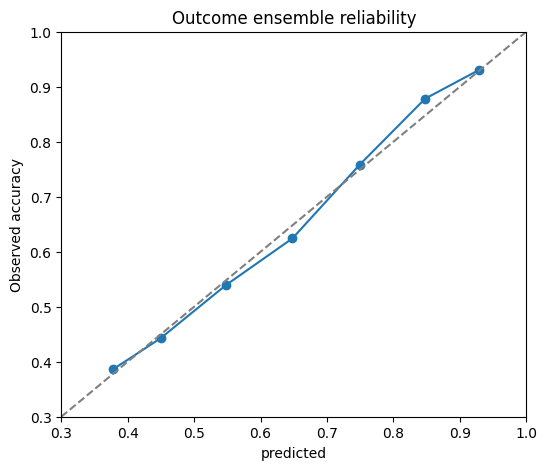

In [5]:
conf, pred = p_ens.max(1), classes[p_ens.argmax(1)]
cal = pd.DataFrame({'confidence':conf,'correct':pred==te.result})
cal['bin'] = pd.cut(cal.confidence, np.linspace(.3,1,8), include_lowest=True)
rel = cal.groupby('bin', observed=True).agg(n=('correct','size'), predicted=('confidence','mean'), observed=('correct','mean'))
display(rel)
ax = rel.plot(x='predicted',y='observed',marker='o',legend=False,figsize=(6,5),title='Outcome ensemble reliability')
ax.plot([.3,1],[.3,1],'--',color='gray'); ax.set(xlim=(.3,1),ylim=(.3,1),ylabel='Observed accuracy'); plt.show()

## 4. Refit outcome models and inspect drivers

After the forward test establishes reasonable performance, both outcome models are refitted using all completed matches through July 18. This is legitimate because those matches are available before the final. `permutation_importance` then shuffles one feature at a time in the test data. If shuffling a feature damages predictions, that feature was useful. Importance describes model reliance, not causation.

,Logistic,Boost,Ensemble
A,29.3%,29.6%,29.4%
D,28.4%,30.4%,29.3%
H,42.4%,40.0%,41.3%


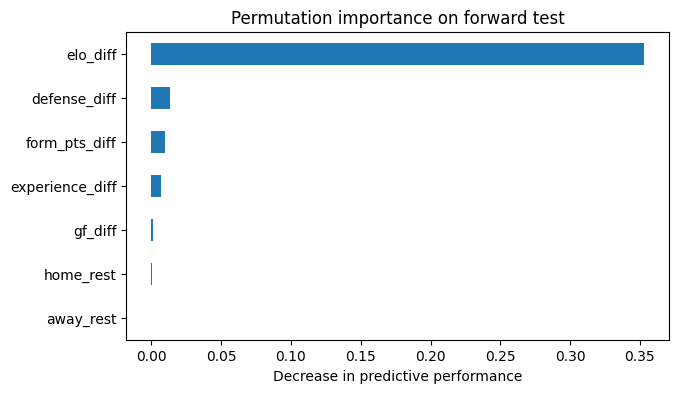

In [6]:
prep_full = clone(prep).fit(model_data[features])
logit_full = clone(logit).fit(prep_full.transform(model_data[features]), model_data.result)
boost_full = clone(boost).fit(model_data[numeric], model_data.result)
pf_log = aligned(logit_full, prep_full.transform(final_x[features]))[0]
pf_boost = aligned(boost_full, final_x[numeric])[0]
outcome90 = .55*pf_log + .45*pf_boost
display(pd.DataFrame({'Logistic':pf_log,'Boost':pf_boost,'Ensemble':outcome90},index=classes).style.format('{:.1%}'))

pi = permutation_importance(boost, te[numeric], te.result, scoring='neg_log_loss', n_repeats=5, random_state=SEED)
imp = pd.Series(pi.importances_mean,index=numeric).sort_values()
imp.plot.barh(figsize=(7,4),title='Permutation importance on forward test'); plt.xlabel('Decrease in predictive performance'); plt.show()

## 5. Goal model

Two regularized Poisson regressions estimate each team's 90-minute goals. The representation is symmetric: one training row per team per match. Team and opponent identities provide partial historical strength information, while Elo/form describe current state.

### Why a Poisson distribution appears in football models

The Poisson distribution models a count occurring within a fixed interval. If a team has expected-goal rate $\lambda$, then

$$P(G=k)=\frac{e^{-\lambda}\lambda^k}{k!},\qquad k=0,1,2,\ldots$$

Suppose Spain's fitted $\lambda$ is 1.23. Then its probability of exactly one goal is

$$P(G=1)=e^{-1.23}(1.23)\approx 0.36.$$

Poisson regression does not directly guess a score. It models the logarithm of the scoring rate from team identity, opponent identity, Elo gap, attacking form, opposing defensive form, and venue:

$$\log(\lambda)=\beta_0+\beta_1x_1+\cdots+\beta_px_p.$$

Exponentiating guarantees $\lambda>0$. Regularization shrinks estimates, especially helpful for teams with fewer matches. Separate random draws from Spain's and Argentina's distributions create a matrix of possible scores; summing cells above, on, and below the diagonal gives win, draw, and loss probabilities.

This is deliberately a second viewpoint. The classifiers learn the result directly; Poisson first models goals and derives the result.

In [7]:
goal_base = model_data.copy()
home = pd.DataFrame({'goals':goal_base.home_score,'team':goal_base.home_team,'opponent':goal_base.away_team,
 'elo_gap':goal_base.elo_diff,'attack':goal_base.home_gf_form,'opp_defense':goal_base.away_ga_form,'is_home':(~goal_base.neutral).astype(int)})
away = pd.DataFrame({'goals':goal_base.away_score,'team':goal_base.away_team,'opponent':goal_base.home_team,
 'elo_gap':-goal_base.elo_diff,'attack':goal_base.away_gf_form,'opp_defense':goal_base.home_ga_form,'is_home':0})
goals = pd.concat([home,away],ignore_index=True)
goal_num = ['elo_gap','attack','opp_defense','is_home']; goal_cat=['team','opponent']
goal_prep = ColumnTransformer([('num',StandardScaler(),goal_num),('cat',OneHotEncoder(handle_unknown='ignore'),goal_cat)])
GX = goal_prep.fit_transform(goals[goal_num+goal_cat])
goal_model = PoissonRegressor(alpha=.6,max_iter=1000).fit(GX,goals.goals)

fh = pd.DataFrame([{'team':FINAL_HOME,'opponent':FINAL_AWAY,'elo_gap':final_x.elo_diff.iloc[0],
 'attack':final_x.home_gf_form.iloc[0],'opp_defense':final_x.away_ga_form.iloc[0],'is_home':0}])
fa = pd.DataFrame([{'team':FINAL_AWAY,'opponent':FINAL_HOME,'elo_gap':-final_x.elo_diff.iloc[0],
 'attack':final_x.away_gf_form.iloc[0],'opp_defense':final_x.home_ga_form.iloc[0],'is_home':0}])
lam_spain = goal_model.predict(goal_prep.transform(fh))[0]
lam_arg = goal_model.predict(goal_prep.transform(fa))[0]
print(f'Expected 90-minute goals — Spain {lam_spain:.2f}, Argentina {lam_arg:.2f}')

Expected 90-minute goals — Spain 1.23, Argentina 1.19


## 6. Monte Carlo: 90 minutes → extra time → penalties

We blend outcome-classifier and Poisson probabilities to reduce dependence on one modeling assumption. Simulations draw a 90-minute state from the blended distribution; scorelines come from Poisson draws conditioned to match that state. Drawn matches get 30-minute Poisson extra time. Remaining ties use a conservative penalty prior centered near 50%, tilted slightly by Elo. This distinguishes **90-minute result** from **trophy winner**.

### Exactly how one simulated final is generated

First combine the direct classifier and goal-derived views:

$$p_{90}=0.60p_{classifier}+0.40p_{Poisson}.$$

Then one simulation does the following:

1. Randomly select Argentina win, draw, or Spain win using $p_{90}$.
2. Draw Spain and Argentina goals from their Poisson distributions and adjust them to be consistent with that selected result.
3. If level, draw extra-time goals using one-third of each 90-minute rate because extra time lasts 30 rather than 90 minutes.
4. If still level, draw a penalty winner. The probability begins at 50% and receives only a small Elo-based tilt, capped between 44% and 56%.
5. Record who lifts the trophy.

Repeat this 200,000 times. If Spain wins 107,000 runs, its estimated trophy probability is

$$107{,}000/200{,}000=53.5\%.$$

The random simulation error near 50% is approximately

$$\sqrt{p(1-p)/N}\approx\sqrt{0.5(0.5)/200000}=0.0011,$$

or about 0.11 percentage points. This numerical noise is tiny compared with uncertainty about features, model form, lineups, and assumptions.

### An important modeling caveat

Conditioning independently drawn goals to agree with a preselected result is a pragmatic way to join the classifier with score simulation. It is not a unique probability model. A more advanced version could fit a joint bivariate-Poisson or Dixon–Coles model and blend at the score-distribution level.

In [8]:
from scipy.stats import poisson

maxg = 10
grid = np.outer(poisson.pmf(np.arange(maxg+1),lam_spain),poisson.pmf(np.arange(maxg+1),lam_arg))
poisson90 = np.array([np.tril(grid,-1).sum(),np.trace(grid),np.triu(grid,1).sum()]) # A,D,H
poisson90 /= poisson90.sum()
blend90 = .60*outcome90 + .40*poisson90

N=200_000
states = RNG.choice(3,size=N,p=blend90) # A,D,H
sg = RNG.poisson(lam_spain,size=N); ag = RNG.poisson(lam_arg,size=N)
# Make sampled scorelines consistent with the sampled outcome state.
for state in range(3):
    idx=np.where(states==state)[0]
    if state==0: sg[idx]=np.minimum(sg[idx],np.maximum(0,ag[idx]-1)); ag[idx]=np.maximum(ag[idx],sg[idx]+1)
    elif state==1: ag[idx]=sg[idx]
    else: ag[idx]=np.minimum(ag[idx],np.maximum(0,sg[idx]-1)); sg[idx]=np.maximum(sg[idx],ag[idx]+1)

draw_idx=np.where(states==1)[0]
et_s=RNG.poisson(lam_spain/3,len(draw_idx)); et_a=RNG.poisson(lam_arg/3,len(draw_idx))
sg[draw_idx]+=et_s; ag[draw_idx]+=et_a
still=draw_idx[et_s==et_a]
pen_spain=np.clip(.5 + final_x.elo_diff.iloc[0]/4000, .44, .56)
spain_pen=RNG.random(len(still)) < pen_spain
spain_wins=(sg>ag); spain_wins[still]=spain_pen

winner = pd.Series({'Spain':spain_wins.mean(),'Argentina':1-spain_wins.mean()})
summary = pd.DataFrame({'90-min probability':blend90},index=['Argentina win','Draw','Spain win'])
display(summary.style.format('{:.1%}'))
display(winner.to_frame('Lift trophy').style.format('{:.1%}'))
print('Most common simulated final scores (after ET when needed):')
display(pd.Series(list(zip(sg,ag))).value_counts(normalize=True).head(10).rename('probability').to_frame().style.format('{:.1%}'))

,90-min probability
Argentina win,32.5%
Draw,28.6%
Spain win,38.9%


,Lift trophy
Spain,53.5%
Argentina,46.5%


Most common simulated final scores (after ET when needed):


,probability
"(np.int64(1), np.int64(0))",27.0%
"(np.int64(0), np.int64(1))",23.2%
"(np.int64(2), np.int64(1))",7.9%
"(np.int64(1), np.int64(2))",6.9%
"(np.int64(1), np.int64(1))",5.1%
"(np.int64(0), np.int64(0))",3.7%
"(np.int64(2), np.int64(2))",3.6%
"(np.int64(2), np.int64(0))",2.9%
"(np.int64(3), np.int64(2))",2.5%
"(np.int64(0), np.int64(2))",2.4%


## 7. Sensitivity and final verdict

Model uncertainty matters more than Monte Carlo noise. We vary the blend weight and each side's expected goals by ±10%. If the favorite changes under plausible assumptions, the honest conclusion is “too close to call.”

Sensitivity analysis asks: **does the answer survive reasonable changes to our choices?** It repeats the calculation while changing the classifier weight and multiplying each expected-goal estimate by 0.9, 1.0, or 1.1. The reported minimum and maximum are not a formal statistical confidence interval. They are a scenario range showing how fragile the favorite is. Because that range crosses 50%, the model's most honest message is “Spain by a very small margin; essentially a toss-up.”

In [9]:
rows=[]
for w in [.4,.6,.8]:
 for sm in [.9,1,1.1]:
  for am in [.9,1,1.1]:
   g=np.outer(poisson.pmf(np.arange(16),lam_spain*sm),poisson.pmf(np.arange(16),lam_arg*am))
   pp=np.array([np.tril(g,-1).sum(),np.trace(g),np.triu(g,1).sum()]); pp/=pp.sum()
   p=w*outcome90+(1-w)*pp
   # Approximate trophy probability: decisive Spain win + half of 90-minute draws.
   rows.append((w,sm,am,p[2]+.5*p[1]))
sens=pd.DataFrame(rows,columns=['classifier_weight','Spain_xG_multiplier','Argentina_xG_multiplier','Spain_trophy_prob'])
display(sens.groupby('classifier_weight').Spain_trophy_prob.agg(['min','mean','max']).style.format('{:.1%}'))

fav=winner.idxmax(); prob=winner.max()
print(f'VERDICT: {fav} is the model favorite with a {prob:.1%} chance to lift the trophy.')
print(f'Sensitivity range for Spain: {sens.Spain_trophy_prob.min():.1%}–{sens.Spain_trophy_prob.max():.1%}.')
print('Treat this as an analytical estimate, not betting advice.')

,min,mean,max
classifier_weight,,,
0.400000,48.3%,51.8%,55.3%
0.600000,50.9%,53.2%,55.5%
0.800000,53.4%,54.6%,55.7%


VERDICT: Spain is the model favorite with a 53.5% chance to lift the trophy.
Sensitivity range for Spain: 48.3%–55.7%.
Treat this as an analytical estimate, not betting advice.


## Limitations and responsible interpretation

- The dataset has match scores, not confirmed lineups, injuries, player minutes, xG, tactics, travel, or market odds.
- Shootouts are sparse and structurally random, so the penalty model is deliberately conservative.
- National-team regimes change; Elo and exponentially weighted form help, but do not fully solve concept drift.
- Poisson assumes a simplified scoring process and can understate score dependence.
- Hyperparameters are reasonable defaults rather than exhaustively searched; the chronological holdout is kept honest.
- A 55% forecast means the predicted loser should still win almost half the time.

**Reproducibility:** rerun all cells top-to-bottom. The seed is fixed; source URL, cutoff date, feature definitions, model weights, and simulation assumptions are visible and editable.